In [ ]:
import string
import numpy as np
from PIL import Image
import os
from pickle import dump, load
import numpy as np

from keras.preprocessing.image import load_img, img_to_array
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from tensorflow.keras.layers import add
from keras.models import Model, load_model
from keras.layers import Input, Dense, LSTM, Embedding, Dropout
from transformers import ViTFeatureExtractor, ViTModel
import torch

# small library for seeing the progress of loops.
from tqdm.notebook import tqdm
# tqdm().pandas()

In [2]:
# Loading a text file into memory
def load_doc(filename):
    # Opening the file as read only
    file = open(filename, 'r')
    text = file.read()
    file.close()
    return text

# get all imgs with their captions
def all_img_captions(filename):
    file = load_doc(filename)
    captions = file.split('\n')
    descriptions ={}
    for caption in captions[:-1]:
        img, caption = caption.split('\t')
        if img[:-2] not in descriptions:
            descriptions[img[:-2]] = [ caption ]
        else:
            descriptions[img[:-2]].append(caption)
    return descriptions

#Data cleaning- lower casing, removing puntuations and words containing numbers
def cleaning_text(captions):
    table = str.maketrans('','',string.punctuation)
    for img,caps in captions.items():
        for i,img_caption in enumerate(caps):

            img_caption.replace("-"," ")
            desc = img_caption.split()

            #converts to lowercase
            desc = [word.lower() for word in desc]
            #remove punctuation from each token
            desc = [word.translate(table) for word in desc]
            #remove hanging 's and a 
            desc = [word for word in desc if(len(word)>1)]
            #remove tokens with numbers in them
            desc = [word for word in desc if(word.isalpha())]
            #convert back to string

            img_caption = ' '.join(desc)
            captions[img][i]= img_caption
    return captions

def text_vocabulary(descriptions):
    # build vocabulary of all unique words
    vocab = set()

    for key in descriptions.keys():
        [vocab.update(d.split()) for d in descriptions[key]]

    return vocab

#All descriptions in one file 
def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + '\t' + desc )
    data = "\n".join(lines)
    file = open(filename,"w")
    file.write(data)
    file.close()


In [5]:


# Set these path according to project folder in you system
# dataset_text = "D:\dataflair projects\Project - Image Caption Generator\Flickr_8k_text"
# dataset_images = "D:\dataflair projects\Project - Image Caption Generator\Flicker8k_Dataset"
dataset_text = "dataset/Flickr8k_text"
dataset_images = "dataset/Flicker8k_Dataset"

#we prepare our text data
filename = dataset_text + "/" + "Flickr8k.token.txt"
#loading the file that contains all data
#mapping them into descriptions dictionary img to 5 captions
descriptions = all_img_captions(filename)
print("Length of descriptions =" ,len(descriptions))

#cleaning the descriptions
clean_descriptions = cleaning_text(descriptions)

#building vocabulary 
vocabulary = text_vocabulary(clean_descriptions)
print("Length of vocabulary = ", len(vocabulary))

#saving each description to file 
save_descriptions(clean_descriptions, "descriptions.txt")

Length of descriptions = 8092
Length of vocabulary =  8763


In [ ]:
# def extract_features(directory):
#         model = Xception( include_top=False, pooling='avg' )
#         features = {}
#         for img in tqdm(os.listdir(directory)):
#             filename = directory + "/" + img
#             image = Image.open(filename)
#             image = image.resize((299,299))
#             image = np.expand_dims(image, axis=0)
#             #image = preprocess_input(image)
#             image = image/127.5
#             image = image - 1.0

#             feature = model.predict(image)
#             features[img] = feature
#         return features


feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

def extract_features_vit(directory):
    features = {}
    for img_name in tqdm(os.listdir(directory)):
        path = os.path.join(directory, img_name)
        image = Image.open(path).convert("RGB")

        # Preprocess image
        inputs = feature_extractor(images=image, return_tensors="pt")

        # Extract features with ViT
        with torch.no_grad():
            outputs = vit_model(**inputs)
        
        # Mean pool all patch embeddings (excluding CLS token if you want)
        pooled_features = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        features[img_name] = pooled_features  # Shape: (768,)
    
    return features


In [ ]:

#768 feature vector for ViT
features = extract_features_vit(dataset_images)
dump(features, open("features.p","wb"))

In [ ]:
#load the data 
def load_photos(filename):
    file = load_doc(filename)
    photos = file.split("\n")[:-1]
    return photos


def load_clean_descriptions(filename, photos): 
    #loading clean_descriptions
    file = load_doc(filename)
    descriptions = {}
    for line in file.split("\n"):

        words = line.split()
        if len(words)<1 :
            continue

        image, image_caption = words[0], words[1:]

        if image in photos:
            if image not in descriptions:
                descriptions[image] = []
            desc = '<start> ' + " ".join(image_caption) + ' <end>'
            descriptions[image].append(desc)

    return descriptions


def load_features(photos):
    #loading all features
    all_features = load(open("features.p","rb"))
    #selecting only needed features
    features = {k:all_features[k] for k in photos}
    return features



filename = dataset_text + "/" + "Flickr_8k.trainImages.txt"

#train = loading_data(filename)
train_imgs = load_photos(filename)
train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
train_features = load_features(train_imgs)

In [4]:
#converting dictionary to clean list of descriptions
def dict_to_list(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc

#creating tokenizer class 
#this will vectorise text corpus
#each integer will represent token in dictionary

from keras.preprocessing.text import Tokenizer

def create_tokenizer(descriptions):
    desc_list = dict_to_list(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(desc_list)
    return tokenizer


In [ ]:

# give each word an index, and store that into tokenizer.p pickle file
tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open('tokenizer.p', 'wb'))
vocab_size = len(tokenizer.word_index) + 1
vocab_size

In [7]:
#calculate maximum length of descriptions
def max_length(descriptions):
    desc_list = dict_to_list(descriptions)
    return max(len(d.split()) for d in desc_list)
    
max_length = max_length(descriptions)
max_length

NameError: name 'descriptions' is not defined

### Data Generator

In [ ]:
#create 
# 
# -output sequence pairs from the image description.

#data generator, used by model.fit_generator()
def data_generator(descriptions, features, tokenizer, max_length):
    while 1:
        for key, description_list in descriptions.items():
            #retrieve photo features
            feature = features[key][0]
            input_image, input_sequence, output_word = create_sequences(tokenizer, max_length, description_list, feature)
            yield [[input_image, input_sequence], output_word]

def create_sequences(tokenizer, max_length, desc_list, feature):
    X1, X2, y = list(), list(), list()
    # walk through each description for the image
    for desc in desc_list:
        # encode the sequence
        seq = tokenizer.texts_to_sequences([desc])[0]
        # split one sequence into multiple X,y pairs
        for i in range(1, len(seq)):
            # split into input and output pair
            in_seq, out_seq = seq[:i], seq[i]
            # pad input sequence
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            # encode output sequence
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            # store
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)
    return np.array(X1), np.array(X2), np.array(y)

#You can check the shape of the input and output for your model
[a,b],c = next(data_generator(train_descriptions, features, tokenizer, max_length))
a.shape, b.shape, c.shape
#((47, 2048), (47, 32), (47, 7577))

NameError: name 'features' is not defined

### Transformer model 



In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# class Transformer(nn.Module):
#     def __init__(
#         self,
#         embedding_size,
#         src_vocab_size,
#         trg_vocab_size,
#         src_pad_idx,
#         num_heads,
#         num_encoder_layers,
#         num_decoder_layers,
#         forward_expansion,
#         dropout,
#         max_len_s,
#         max_len_t,
#         device,
#     ):
#         super(Transformer, self).__init__()
#         self.src_word_embedding = nn.Embedding(src_vocab_size, embedding_size)
#         self.src_position_embedding = nn.Embedding(max_len_s, embedding_size)
#         self.trg_word_embedding = nn.Embedding(trg_vocab_size, embedding_size)
#         self.trg_position_embedding = nn.Embedding(max_len_t, embedding_size)

#         self.device = device
#         self.transformer = nn.Transformer(
#             embedding_size,
#             num_heads,
#             num_encoder_layers,
#             num_decoder_layers,
#             forward_expansion,
#             dropout,
#         )
#         self.fc_out = nn.Linear(embedding_size, trg_vocab_size)
#         self.dropout = nn.Dropout(dropout)
#         self.src_pad_idx = src_pad_idx

#     def make_src_mask(self, src):
#         src_mask = src.transpose(0, 1) == self.src_pad_idx

#         # (N, src_len)
#         return src_mask.to(self.device)

#     def forward(self, src, trg):
#         src_seq_length, N = src.shape
#         trg_seq_length, N = trg.shape

#         src_positions = (
#             torch.arange(0, src_seq_length)
#             .unsqueeze(1)
#             .expand(src_seq_length, N)
#             .to(self.device)
#         )

#         trg_positions = (
#             torch.arange(0, trg_seq_length)
#             .unsqueeze(1)
#             .expand(trg_seq_length, N)
#             .to(self.device)
#         )

#         embed_src = self.dropout(
#             (self.src_word_embedding(src) + self.src_position_embedding(src_positions))
#         )
#         embed_trg = self.dropout(
#             (self.trg_word_embedding(trg) + self.trg_position_embedding(trg_positions))
#         )

#         src_padding_mask = self.make_src_mask(src)
#         trg_mask = self.transformer.generate_square_subsequent_mask(trg_seq_length).to(self.device)
#         out = self.transformer(
#             embed_src,
#             embed_trg,
#             src_key_padding_mask=src_padding_mask,
#             tgt_mask=trg_mask,
#         )
#         out = self.fc_out(out)
#         return out

In [ ]:
# # Model hyperparameters
# src_vocab_size = 256
# trg_vocab_size = len(token_Sentence.word_index)
# embedding_size = 512
# num_heads = 8
# num_encoder_layers = 3
# num_decoder_layers = 3
# dropout = 0.10
# max_len_s = Images.shape[1]
# max_len_t = len(Sentence[0])
# forward_expansion = 4
# src_pad_idx = 0

# # Training hyperparameters
# num_epochs = 10000
# learning_rate = 3e-4
# batch_size = 1

In [ ]:
# model = Transformer(
#     embedding_size,
#     src_vocab_size,
#     trg_vocab_size,
#     src_pad_idx,
#     num_heads,
#     num_encoder_layers,
#     num_decoder_layers,
#     forward_expansion,
#     dropout,
#     max_len_s,
#     max_len_t,
#     device,
# ).to(device)

# optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, factor=0.1, patience=10, verbose=True
# )

# pad_idx = 0
# criterion = nn.CrossEntropyLoss(ignore_index=pad_idx).cuda()

In [ ]:
def define_model(vocab_size, max_length):
    inputs1 = Input(shape=(768,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model

model = define_model(vocab_size, max_length)
model.summary()


### Training

In [ ]:
# train our model
print('Dataset: ', len(train_imgs))
print('Descriptions: train=', len(train_descriptions))
print('Photos: train=', len(train_features))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_length)


from keras.utils import to_categorical
import numpy as np

# Load extracted ViT features
features = load(open("vit_features.pkl", "rb"))

# Create sequences for training
def create_sequences(tokenizer, max_length, descriptions, photos, vocab_size):
    X1, X2, y = [], [], []

    for key, desc_list in descriptions.items():
        if key not in photos:
            continue
        for desc in desc_list:
            seq = tokenizer.texts_to_sequences([desc])[0]
            for i in range(1, len(seq)):
                in_seq, out_seq = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                X1.append(photos[key])
                X2.append(in_seq)
                y.append(out_seq)
    
    return np.array(X1), np.array(X2), np.array(y)

# Prepare data
X1train, X2train, ytrain = create_sequences(tokenizer, max_length, descriptions, features, vocab_size)

# Train the model
model.fit([X1train, X2train], ytrain, epochs=20, batch_size=64, verbose=1)

# Save the trained model
model.save("vit_caption_model.h5")


# model = define_model(vocab_size, max_length)
# epochs = 10
# steps = len(train_descriptions)
# # making a directory models to save our models
# os.mkdir("models")
# for i in range(epochs):
#     generator = data_generator(train_descriptions, train_features, tokenizer, max_length)
#     model.fit_generator(generator, epochs=1, steps_per_epoch= steps, verbose=1)
#     model.save("models/model_" + str(i) + ".h5")

# import time
# def train():
#     model.train() # Turn on the train mode
#     total_loss = 0
#     start_time = time.time()
#     for i in range(1, 999):
#         src,tar = create_batch(Images,Sentence, batch_size , i)
#         src = src.to(device)
#         tar = tar.to(device)
#         optimizer.zero_grad()
#         output = model(src,tar)
#         loss = criterion(output.view(-1, output.shape[2]), tar.reshape(-1))
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
#         optimizer.step()
#         cur_loss = loss.item()
#         total_loss += cur_loss
#         log_interval = 100
#         if i % log_interval == 0 and i > 0:
#             elapsed = time.time() - start_time
#             print('| epoch {:3d} | {:5d}/{:5d} batches | '
#                   's/batch {:5.2f} | '
#                   'loss {:5.2f} | ppl {:8.2f}'.format(
#                     epoch, i, (src.shape[1]) // batch_size, 
#                     elapsed  / log_interval,
#                     cur_loss, math.exp(cur_loss)))
#             start_time = time.time()
#     return total_loss



Dataset:  6000
Descriptions: train= 6000
Photos: train= 6000
Vocabulary Size: 7577
Description Length:  32
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 32)]                 0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 2048)]               0         []                            
                                                                                                  
 embedding (Embedding)       (None, 32, 256)              1939712   ['input_3[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 2048)                 0         ['input_2[0][0]'] 

/var/folders/w3/0kb6sk8s79x5102b781dnbjh0000gn/T/ipykernel_4812/2846483122.py:15: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(generator, epochs=1, steps_per_epoch= steps, verbose=1)


   1/6000 [..............................] - ETA: 6:11 - loss: 4.2581

/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


6000/6000 [==============================] - 367s 61ms/step - loss: 2.7974


In [ ]:
import math
for epoch in range(1, 3):
    epoch_start_time = time.time()
    loss = train()
    print('-' * 89)
    print('| end of epoch {:3d} | time: {:5.2f}s | Training loss {:5.2f} | '
          .format(epoch, (time.time() - epoch_start_time),
                                     loss))

### Testing 

1/1 [==============================] - 0s 296ms/step



start two children are playing soccer on the grass end


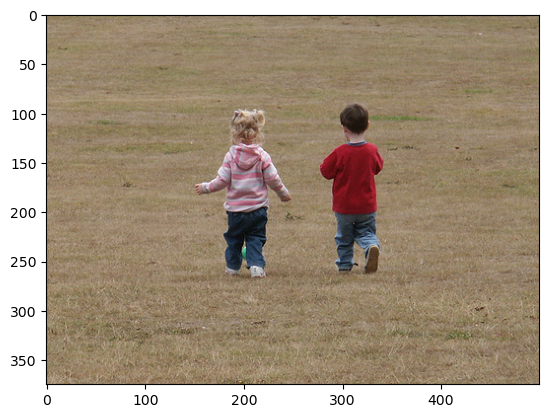

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import argparse


# ap = argparse.ArgumentParser()
# ap.add_argument('-i', '--image', required=True, help="Image Path")
# args = vars(ap.parse_args())
# img_path = args['image']

def display_image(name):
    img = image.load_img(name,target_size=(512,512,3))
    img = image.img_to_array(img)
    img = img/255
    plt.imshow(img)
    
def extract_features(filename, model):
        try:
            image = Image.open(filename)

        except:
            print("ERROR: Couldn't open image! Make sure the image path and extension is correct")
        image = image.resize((299,299))
        image = np.array(image)
        # for images that has 4 channels, we convert them into 3 channels
        if image.shape[2] == 4: 
            image = image[..., :3]
        image = np.expand_dims(image, axis=0)
        image = image/127.5
        image = image - 1.0
        feature = model.predict(image)
        return feature

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None


def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        pred = model.predict([photo,sequence], verbose=0)
        pred = np.argmax(pred)
        word = word_for_id(pred, tokenizer)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'end':
            break
    return in_text


img_path = 'dataset/Flicker8k_Dataset/438639005_208bc59b0b.jpg'
# img_path = '/Users/abhinandanvijan/Downloads/WhatsApp Image 2025-01-17 at 20.18.50.jpeg'
max_length = 32
tokenizer = load(open("tokenizer.p","rb"))
model = load_model('models/model_8.h5')
xception_model = Xception(include_top=False, pooling="avg")

photo = extract_features(img_path, xception_model)
img = Image.open(img_path)

description = generate_desc(model, tokenizer, photo, max_length)
print("\n\n")
print(description)
plt.imshow(img)

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/abhinandanvijan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


1/1 [==============================] - 0s 278ms/step

Generated Caption: dog running through the snow

Evaluation Scores:
BLEU-1 Score: 0.6703
BLEU-2 Score: 0.4740
BLEU-3 Score: 0.0000
BLEU-4 Score: 0.0000
METEOR Score: 0.5515


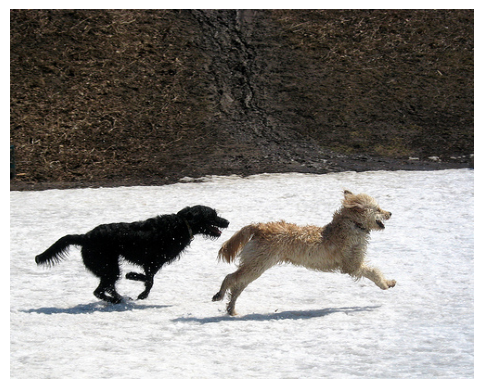

In [31]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from keras.models import load_model
from keras.preprocessing.sequence import pad_sequences
from pickle import load
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.meteor_score import meteor_score
from tensorflow.keras.applications.xception import Xception
import nltk

# Download METEOR resources
nltk.download('wordnet')

def extract_features(filename, model):
    try:
        image = Image.open(filename)
    except:
        print("ERROR: Couldn't open image! Make sure the image path and extension is correct")
        return None
    image = image.resize((299, 299))
    image = np.array(image)
    if image.shape[-1] == 4:  # Convert RGBA to RGB
        image = image[..., :3]
    image = np.expand_dims(image, axis=0)
    image = image / 127.5 - 1.0
    feature = model.predict(image)
    return feature

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        pred = model.predict([photo, sequence], verbose=0)
        pred = np.argmax(pred)
        word = word_for_id(pred, tokenizer)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'end':
            break
    return in_text

# Load tokenizer and model
tokenizer = load(open("tokenizer.p", "rb"))
model = load_model('models/model_8.h5')
xception_model = Xception(include_top=False, pooling="avg")

# Function to load ground truth captions from descriptions.txt
def load_ground_truth(file_path):
    ground_truth_dict = {}
    with open(file_path, 'r') as f:
        for line in f:
            image, caption = line.split('\t')
            if image not in ground_truth_dict:
                ground_truth_dict[image] = []
            ground_truth_dict[image].append(caption.strip())
    return ground_truth_dict

# Load ground truth captions
ground_truth_dict = load_ground_truth('descriptions.txt')

# Image path
img_path = 'dataset/Flicker8k_Dataset/2513260012_03d33305cf.jpg'

# Extract features
photo = extract_features(img_path, xception_model)
if photo is None:
    exit()

# Generate description
max_length = 32
generated_caption = generate_desc(model, tokenizer, photo, max_length)
generated_caption = generated_caption.replace("start", "").replace("end", "").strip()

# Get ground truth captions for the current image
image_id = img_path.split('/')[-1]  # Extract image filename (e.g., 1000268201_693b08cb0e.jpg)
ground_truth_captions = ground_truth_dict.get(image_id, [])

# Tokenize the generated caption (split it into words)
generated_caption_tokens = generated_caption.split()

# Tokenize the ground truth captions (split each caption into words)
ground_truth_tokens = [caption.split() for caption in ground_truth_captions]

# BLEU Score (higher is better)
bleu1 = sentence_bleu(ground_truth_tokens, generated_caption_tokens, weights=(1, 0, 0, 0))  # BLEU-1
bleu2 = sentence_bleu(ground_truth_tokens, generated_caption_tokens, weights=(0.5, 0.5, 0, 0))  # BLEU-2
bleu3 = sentence_bleu(ground_truth_tokens, generated_caption_tokens, weights=(0.33, 0.33, 0.33, 0))  # BLEU-3
bleu4 = sentence_bleu(ground_truth_tokens, generated_caption_tokens, weights=(0.25, 0.25, 0.25, 0.25))  # BLEU-4

# METEOR Score (higher is better)
meteor = meteor_score(ground_truth_tokens, generated_caption_tokens)

# Print scores
print("\nGenerated Caption:", generated_caption)
print("\nEvaluation Scores:")
print(f"BLEU-1 Score: {bleu1:.4f}")
print(f"BLEU-2 Score: {bleu2:.4f}")
print(f"BLEU-3 Score: {bleu3:.4f}")
print(f"BLEU-4 Score: {bleu4:.4f}")
print(f"METEOR Score: {meteor:.4f}")

# Display image
img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()


## Testing gradio

In [ ]:



# import gradio as gr
# import numpy as np
# from tensorflow.keras.models import load_model
# from PIL import Image

# # Load trained image captioning model
# model = load_model('models/model_8.h5') 

# def generate_caption(img_path):
#     # Open and preprocess the image
#     # image = Image.open(image_path).convert("RGB")
#     # image = image.resize((224, 224))
#     # image = np.array(image) / 255.0
#     # image = np.expand_dims(image, axis=0)

#     # # Generate caption (assuming model.predict() returns a caption)
#     # caption = model.predict(image)
    
#     # return f"Generated Caption: {caption}"

#     max_length = 32
#     tokenizer = load(open("tokenizer.p","rb"))
#     model = load_model('models/model_8.h5')
#     xception_model = Xception(include_top=False, pooling="avg")

#     photo = extract_features(img_path, xception_model)
#     img = Image.open(img_path)

#     description = generate_desc(model, tokenizer, photo, max_length)

#     print(description)

#     return f"Generated Caption: {description}"

# # Create Gradio UI
# iface = gr.Interface(
#     fn=generate_caption,
#     inputs=gr.Image(type="filepath"),  # ✅ Corrected type
#     outputs="text",
#     title="Image Caption Generator",
#     description="Upload an image to generate a caption."
# )

# iface.launch()


In [ ]:
import gradio as gr
import sqlite3
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image
import io
import pickle
from tensorflow.keras.applications.xception import Xception

# Load trained image captioning model
model = load_model('models/model_8.h5')

# SQLite database file
DB_FILE = "images.db"

# Create table if not exists
def init_db():
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS images (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                image BLOB NOT NULL,
                caption TEXT NOT NULL
            )
        ''')
        conn.commit()

init_db()

def generate_caption(img_path):
    max_length = 32
    tokenizer = pickle.load(open("tokenizer.p", "rb"))
    xception_model = Xception(include_top=False, pooling="avg")

    photo = extract_features(img_path, xception_model)
    img = Image.open(img_path)

    description = generate_desc(model, tokenizer, photo, max_length)

    print(description)
    saveImageDesc(img_path, description)

    return f"Generated Caption: {description}"

def saveImageDesc(img_path, caption):
    img = Image.open(img_path)

    # Convert image to bytes for storing in SQLite
    img_bytes = io.BytesIO()
    img.save(img_bytes, format="PNG")
    img_data = img_bytes.getvalue()

    # Store in SQLite
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("INSERT INTO images (image, caption) VALUES (?, ?)", (img_data, caption))
        conn.commit()
        print(f"{img_path} added to database.")

# **Updated Search Function for Multiple Images**
def search_images(keyword):
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT image FROM images WHERE caption LIKE ?", ('%' + keyword + '%',))
        rows = cursor.fetchall()  # Fetch all matching rows

    if rows:
        images = [Image.open(io.BytesIO(row[0])) for row in rows]  # Convert binary data to images
        # Return the list of images as a Gradio gallery, set columns to 2 directly
        return gr.Gallery(images, columns=2)  # Display images in 2 columns
    else:
        return gr.Gallery([])  # Return a message if no image is found

# Create Gradio UI for caption generation
iface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="filepath"),
    outputs="text",
    title="Image Caption Generator",
    description="Upload an image to generate a caption and store it locally."
)

# Create Gradio UI for searching images by caption
search_iface = gr.Interface(
    fn=search_images,
    inputs="text",
    outputs=gr.Gallery(),  # Use Gallery to display multiple images
    title="Search Images by Caption",
    description="Enter a keyword to find images stored in SQLite.",
    examples=[["man"], ["dog"], ["nature"]]  # Add sample keywords for testing
)

# Launch both interfaces in tabs
gr.TabbedInterface([iface, search_iface], ["Generate Caption", "Search Images"]).launch()


Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------
IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------
IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------
1/1 [==============================] - 0s 276ms/step
start man in red shirt is standing on the grass near the water end
/private/var/folders/w3/0kb6sk8s79x5102b781dnbjh0000gn/T/gradio/c9baf418b7d2251cb5671c7976073ebf04e7f2a5/park.jpeg added to database.
1/1 [==============================] - 0s 276ms/step
start baby in pink bathing suit is jumping into pool end
/private/var/folders/w3/0kb6sk8s79x5102b781dnbjh0000gn/T/gradio/002092d4b1a32444621b059365a3f57f9509d9e1/3758175529_81941e7cc9.jpeg added to database.
1/1 [==============================] - 0s 271ms/step
start two children are playing on the grass end
/private/var/folders/w3/0kb6sk8s79x5102b781dnbjh0000gn